# T2-prepared gradient echo

A gradient echo has no $T_2$ contrast. Its signal decays at $T_2^*$, which includes everything
static the magnet and the tissue interface do, and at the short echo times a fast scan needs there
is barely any decay at all. So a spoiled GRE is a $T_1$-weighted or proton-density-weighted
sequence, and no choice of echo time turns it into a $T_2$-weighted one.

A **$T_2$ preparation** puts the contrast in before the imaging starts:

```text
90x  ->  refocusing train  ->  tip-up  ->  spoiler  ->  imaging train
     |<------ prep_time_s ------>|
```

The first pulse tips the magnetisation into the transverse plane, where it decays. A train of
refocusing pulses reverses static dephasing while it sits there, so what it decays at is $T_2$ and
not $T_2^*$. The tip-up returns what survives to the longitudinal axis, and a spoiler destroys
whatever is left transverse. The imaging train then reads **longitudinal** magnetisation that has
already been scaled by

$$S \;\propto\; e^{-\mathrm{prep\_time\_s} / T_2}$$

and it can be any fast readout at all, because the contrast is no longer its job.

`sc.modules.T2Prep` is that preparation. This notebook builds it, checks the emitted block, and
puts it in front of a shipped `GRE2D`.

| | |
|---|---|
| **1** | what the preparation is made of |
| **2** | `prep_time_s`, and the two instants it is measured between |
| **3** | what the emitted block says about itself |
| **4** | composing it with a gradient echo — and the ordering that makes it work |
| **5** | the files |

**Output:** four `.seq` files at preparation times of 0, 30, 50 and 80 ms, which
[`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) plays through a Bloch
simulator to recover $T_2$. **Needs nothing but `seqcraft`.**

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=150, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM, MATRIX, THICKNESS_MM = 220.0, 64, 5.0
PREP_TIMES_S = (0.0, 30e-3, 50e-3, 80e-3)
VOXEL_MM = FOV_MM / MATRIX
SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)
raster = sc.Raster(opts.grad_raster_time)

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. What the preparation is made of

Fifteen hard pulses, and every one of them is played at the **same $B_1$ amplitude**:

```text
90x                                    the tip-down
(90x 180y 90x) x4                      four composite refocusing pulses
270x  360(-x)                          the tip-up: net -90x
```

At a fixed amplitude a flip angle *is* a duration — a 90 is half a 180 and a 360 is twice one —
which is what lets three pulses be glued into one composite that behaves better than a single
180 would. `refocus_duration_s` sets the 180's length and therefore the amplitude every other
pulse inherits.

The refocusing train is what makes this a $T_2$ preparation rather than a $T_2^*$ one, and its
phases follow **MLEV-4**: the four composites are cycled `+ + − −`, which makes the errors of one
pulse cancel against the next rather than accumulate down the train.

In [2]:
prep = sc.modules.T2Prep(opts=opts, prep_time_s=50e-3, spoil_voxel_mm=VOXEL_MM)

print(f'{len(prep.pulses)} pulses, all at B1 = {prep.b1_hz:.0f} Hz '
      f'= {sc.convert(prep.b1_hz, "Hz", "uT"):.1f} uT\n')
print(f'{"#":>3} {"flip / deg":>11} {"phase / deg":>12} {"duration / us":>14}')
for index, rf in enumerate(prep.pulses):
    flip = float(np.abs(np.trapezoid(rf.signal, rf.t)) * 360.0)
    print(f'{index:3d} {flip:11.0f} {np.rad2deg(rf.phase_offset) % 360.0:12.0f} '
          f'{float(pp.calc_duration(rf)) * 1e6:14.0f}')

15 pulses, all at B1 = 500 Hz = 11.7 uT

  #  flip / deg  phase / deg  duration / us
  0          90            0            630
  1          90            0            630
  2         180           90           1130
  3          90            0            630
  4          90            0            630
  5         180           90           1130
  6          90            0            630
  7          90          180            630
  8         180          270           1130
  9          90          180            630
 10          90          180            630
 11         180          270           1130
 12          90          180            630
 13         270            0           1630
 14         360          180           2130


---
## 2. `prep_time_s`, and the two instants it is measured between

The preparation time is the interval the magnetisation spends **transverse**: from the instant the
tip-down rotates it there to the instant the tip-up brings it back. That is the interval the
exponential is over, so it is the one the module books.

It is worth being explicit, because implementations differ. Booking the interval edge to edge —
from the end of the tip-down to the start of the tip-up — is also common, and the two differ by
about one tip-pulse duration. Against a 50 ms preparation that is a few per cent of the quantity
being measured.

The compiled sequence also prints two warnings, both from the imaging train rather than from the
preparation: blocks over the **vector-norm** gradient limit, which the compiler reports as legal
on a real amplifier because no single physical axis exceeds its own. They are collected and
summarised in section 5 rather than printed once per file.

A composite has no single instant at which it rotates, so this module states the rule rather than
leaving it to be inferred: the **amplitude-weighted centre** of the group. For one hard pulse that
is its centre; for the symmetric `90x 180y 90x` composite it is the centre of the 180.

In [3]:
print(f'{"requested / ms":>15} {"realised / ms":>14} {"tip-down at":>13} {"tip-up at":>11}')
for prep_time_s in PREP_TIMES_S[1:]:
    made = sc.modules.T2Prep(opts=opts, prep_time_s=prep_time_s, spoil_voxel_mm=VOXEL_MM)
    print(f'{prep_time_s * 1e3:15.1f} {made.prep_time_s * 1e3:14.4f} '
          f'{made.time_to_tip_down() * 1e3:12.3f}m {made.time_to_tip_up() * 1e3:10.3f}m')
print()
print(f'the shortest these pulses leave room for is {prep.min_prep_time_s * 1e3:.2f} ms, and a '
      f'shorter request is refused')

 requested / ms  realised / ms   tip-down at   tip-up at
           30.0        30.0043        0.350m     30.354m
           50.0        50.0043        0.350m     50.354m
           80.0        80.0043        0.350m     80.354m

the shortest these pulses leave room for is 24.96 ms, and a shorter request is refused


Every group starts on the gradient raster, because the seam between two consecutive pulses is
where a block boundary has to be cut and only raster instants can be cut. So the placement is
quantised first and `prep_time_s` is **measured off it** — it is what the sequence delivers,
within half a raster of the request.

---
## 3. What the emitted block says about itself

Three things have to hold, and all three are read back out of the events rather than taken from
the module.

**The gaps either side of every refocusing pulse must be equal.** Static dephasing accumulated
before a refocusing pulse is only undone if the same time passes after it. That is why the four
composites sit at 1/8, 3/8, 5/8 and 7/8 of the preparation: the four inner gaps are equal and the
two outer ones are half of each.

**No gradient may play while the magnetisation is transverse.** A gradient there would dephase
what the preparation is storing. The only gradient in the block is the spoiler, and it comes
after the tip-up.

**The tip-up must reverse the tip-down.** 270 about $+x$ then 360 about $-x$ is a net $-90$ about
$+x$. Get the sign wrong and the second pulse continues the rotation instead of reversing it: the
prepared magnetisation is destroyed rather than stored, and the sequence still compiles.

In [4]:
gaps = np.array(prep.interval_gaps_s) * 1e3
print('intervals between consecutive rotation instants, ms:')
print('   tip-down -> 1st     ', f'{gaps[0]:8.3f}')
for index in range(1, len(gaps) - 1):
    print(f'   {index} -> {index + 1}               ', f'{gaps[index]:8.3f}')
print('   4th -> tip-up       ', f'{gaps[-1]:8.3f}')
half = gaps[1:-1].mean() / 2.0
print(f'\ninner gaps agree to {np.ptp(gaps[1:-1]) * 1e3:.1f} us; the outer two are within '
      f'{max(abs(gaps[0] - half), abs(gaps[-1] - half)) * 1e3:.1f} us of half of them')

moments = sc.moments(prep(), 0)
print(f'\nthe only gradient in the block is the spoiler: {moments}')
print(f'it starts at {prep.time_to_spoiler() * 1e3:.2f} ms, after the tip-up at '
      f'{prep.time_to_tip_up() * 1e3:.2f} ms')

intervals between consecutive rotation instants, ms:
   tip-down -> 1st         6.250
   1 -> 2                  12.500
   2 -> 3                  12.500
   3 -> 4                  12.500
   4th -> tip-up           6.254

inner gaps agree to 0.0 us; the outer two are within 4.3 us of half of them

the only gradient in the block is the spoiler: {'z': 1163.6363636363571}
it starts at 52.19 ms, after the tip-up at 50.35 ms


---
## 4. Composing it with a gradient echo

The preparation is a leaf: it knows nothing about what follows and imposes nothing on it. A
complete acquisition is the preparation, then a readout train, then enough recovery time before
the next shot.

**The line ordering is the part that matters, and it belongs to the acquisition rather than to the
preparation.** What the preparation stores is longitudinal magnetisation, and longitudinal
magnetisation recovers at $T_1$. Every millisecond between the tip-up and the acquisition of the
**centre of k-space** is a millisecond of that recovery washing the contrast out — and the centre
of k-space is what sets the contrast of the image.

A linear ordering acquires it halfway through the train. A **centric** ordering acquires it first.

In [5]:
gre = sc.modules.GRE2D(opts=opts, fov_mm=FOV_MM, matrix=(MATRIX, MATRIX),
                       thickness_mm=THICKNESS_MM, flip_deg=15.0)
LINEAR = list(range(MATRIX))
CENTRIC = sorted(range(MATRIX), key=lambda line: (abs(line - gre.center_line),
                                                  line >= gre.center_line))

print(f'GRE2D: TE {gre.tr.te_s * 1e3:.2f} ms, TR {gre.tr.tr_s * 1e3:.2f} ms, '
      f'train {gre(lines=LINEAR).duration * 1e3:.0f} ms')
print(f'centric order begins {CENTRIC[:6]} ... centre line is {gre.center_line}')
print()
print(f'{"ordering":>10} {"k = 0 reached after":>21} {"T1 = 1200 ms leaves":>21}')
for name, order in (('linear', LINEAR), ('centric', CENTRIC)):
    delay_s = gre.time_to_center_line(lines=order)
    print(f'{name:>10} {delay_s * 1e3:20.1f}m {np.exp(-delay_s / 1.2) * 100:20.0f} %')

GRE2D: TE 4.62 ms, TR 9.65 ms, train 618 ms
centric order begins [32, 31, 33, 30, 34, 29] ... centre line is 32

  ordering   k = 0 reached after   T1 = 1200 ms leaves
    linear                315.0m                   77 %
   centric                  6.2m                   99 %


Three hundred milliseconds of $T_1$ recovery is most of the preparation thrown away, so this
acquisition uses the centric ordering. That is a decision about the readout, made where the
readout is composed — the preparation has no opinion about it and could not enforce one.

In [6]:
def shot(prep_time_s):
    """One shot: the preparation, then a centrically ordered gradient echo."""
    tree = sc.LogicBlock('t2prep_gre')
    if not prep_time_s:
        tree.add(0.0, gre(lines=CENTRIC))
        return None, tree
    made = sc.modules.T2Prep(opts=opts, prep_time_s=prep_time_s, spoil_voxel_mm=VOXEL_MM)
    tree.add(0.0, made())
    tree.add(float(raster.ceil(made().duration)), gre(lines=CENTRIC))
    return made, tree


print(f'{"prep / ms":>10} {"realised":>10} {"shot / ms":>11} {"blocks":>8} {"file":>28}')
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always', sc.SeqCraftWarning)
    for prep_time_s in PREP_TIMES_S:
        made, tree = shot(prep_time_s)
        name = f't2prep_gre_2d_{int(round(prep_time_s * 1e3)):03d}'
        seq = sc.compile(tree, opts, name=name, definitions={
            'FOV': [FOV_MM / 1e3, FOV_MM / 1e3, THICKNESS_MM / 1e3],
            'prep_time_s': 0.0 if made is None else made.prep_time_s,
        })
        seq.write(str(SEQ_DIR / f'{name}.seq'))
        realised = '-' if made is None else f'{made.prep_time_s * 1e3:.3f}'
        print(f'{prep_time_s * 1e3:10.0f} {realised:>10} {tree.duration * 1e3:11.2f} '
              f'{len(seq.block_events):8d} {"seq/" + name + ".seq":>28}')

print(f'\n{len(caught)} warnings, every one of them from the GRE2D train:')
for kind in sorted({str(w.message).split(':')[0] for w in caught}):
    print(f'   {kind}')

np.savez(SEQ_DIR / 't2prep_gre_2d_nominal.npz',
         matrix=np.array([MATRIX, MATRIX]), fov_mm=np.array([FOV_MM, FOV_MM]),
         thickness_mm=THICKNESS_MM, lines=np.array(CENTRIC),
         center_line=gre.center_line, prep_times_s=np.array(PREP_TIMES_S),
         te_s=gre.tr.te_s, tr_s=gre.tr.tr_s)
print(f'\n-> {SEQ_DIR / "t2prep_gre_2d_nominal.npz"}')

 prep / ms   realised   shot / ms   blocks                         file


         0          -      617.60      256    seq/t2prep_gre_2d_000.seq


        30     30.004      650.75      277    seq/t2prep_gre_2d_030.seq


        50     50.004      670.75      277    seq/t2prep_gre_2d_050.seq


        80     80.004      700.75      277    seq/t2prep_gre_2d_080.seq

4 warnings, every one of them from the GRE2D train:
   192 blocks over the vector-norm limit (legal on real amplifiers)

-> seq/t2prep_gre_2d_nominal.npz


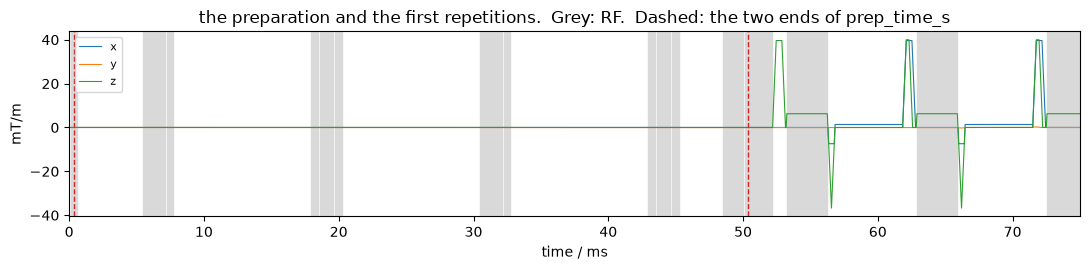

In [7]:
made, tree = shot(50e-3)
grid, grads, spans = sc.sample(tree, opts)
fig, ax = plt.subplots(figsize=(11.0, 2.8))
for axis in ('x', 'y', 'z'):
    if axis in grads:
        ax.plot(grid * 1e3, grads[axis] / 42.576e6 * 1e3, lw=0.8, label=axis)
for kind, start, stop, _path in spans:
    if kind == 'rf':
        ax.axvspan(start * 1e3, stop * 1e3, color='0.85', zorder=0)
ax.axvline(made.time_to_tip_down() * 1e3, color='C3', ls='--', lw=1.0)
ax.axvline(made.time_to_tip_up() * 1e3, color='C3', ls='--', lw=1.0)
ax.set(xlim=(0, 75), xlabel='time / ms', ylabel='mT/m',
       title='the preparation and the first repetitions.  Grey: RF.  '
             'Dashed: the two ends of prep_time_s', )
ax.legend(fontsize=8, loc='upper left')
fig.tight_layout()

Between the dashed lines there are fifteen grey bands and **no gradient at all** — which is the
preparation working. The single gradient after them is the spoiler, and the imaging train starts
after that.

---
## Summary

| | |
|---|---|
| **what it buys** | $T_2$ contrast in a sequence that has none of its own, as a factor $e^{-\mathrm{prep\_time\_s}/T_2}$ on the longitudinal magnetisation |
| **how** | tip down, refocus while it decays, tip back up, spoil what is left |
| **the refocusing train** | four composites at 1/8, 3/8, 5/8 and 7/8, MLEV-4 `+ + − −`, so the gaps either side of each are equal |
| **one $B_1$** | every pulse shares it, so a flip angle is a duration and `refocus_duration_s` sets them all |
| **`prep_time_s`** | the transverse interval, between the effective rotation instants, realised to within half a gradient raster |
| **no gradient inside** | the only one in the block is the spoiler, after the tip-up |
| **the ordering is the caller's** | centric, because $T_1$ recovery between the tip-up and k = 0 is what erodes the contrast |

**What this notebook does not cover.** Anything needing a simulator: the weighting itself is a
claim about magnetisation and [`02`](02_simulate_and_reconstruct.ipynb) measures it. Nor $B_0$ and
$B_1$ robustness, which is what an *adiabatic* tip pair buys and this mode does not have; the
composite pulses here help, and no quantitative claim is made about how much.

## References

- M. A. Bernstein, K. F. King and X. J. Zhou, *Handbook of MRI Pulse Sequences*, Elsevier 2004,
  §17.4 — the preparation, its non-selectivity, and why the imaging that follows is ordered
  centrically.
- M. H. Levitt and R. Freeman, "NMR population inversion using a composite pulse",
  *J. Magn. Reson.* **33**, 473 (1979); and *J. Magn. Reson.* **43**, 65 (1981) — composite pulses
  and the MLEV cycles.
- J. H. Brittain et al., "Coronary angiography with magnetization-prepared T2 contrast",
  *Magn. Reson. Med.* **33**, 689 (1995).